In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(
    "cleaned_data.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,December,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,December,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,December,Tuesday,7


In [3]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [4]:
rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x: (reference_date - x.max()).days,

    "Invoice":"nunique",

    "Revenue":"sum"

})

rfm.columns=["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [5]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [6]:
customer_orders = (
    df.groupby("Customer ID")["Invoice"]
      .count()
)

rfm["Total_Items"] = customer_orders

rfm["Average_Order_Value"] = (
    rfm["Monetary"] /
    rfm["Frequency"]
)

rfm["CLV"] = (
    rfm["Monetary"] *
    rfm["Frequency"]
)

rfm.head()

,Recency,Frequency,Monetary,Total_Items,Average_Order_Value,CLV
Customer ID,,,,,,
12346.0,326,12,77556.46,34,6463.038333,930677.52
12347.0,2,8,4921.53,222,615.191250,39372.24
12348.0,75,5,2019.40,51,403.880000,10097.00
12349.0,19,4,4428.69,175,1107.172500,17714.76
12350.0,310,1,334.40,17,334.400000,334.40


In [7]:
rfm.isnull().sum()

Recency                0
Frequency              0
Monetary               0
Total_Items            0
Average_Order_Value    0
CLV                    0
dtype: int64

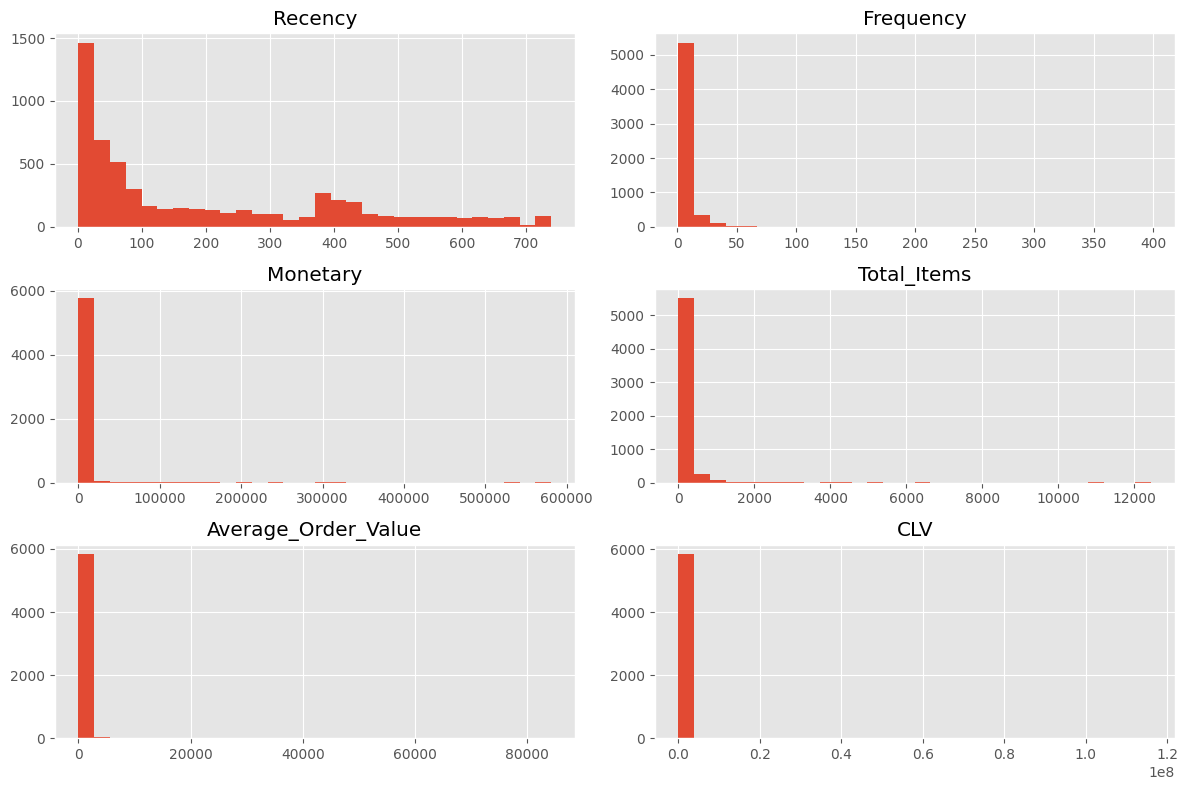

In [8]:
rfm.hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

In [9]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Items",
    "Average_Order_Value",
    "CLV"
]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    rfm[features]
)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features
)

scaled_df.head()

,Recency,Frequency,Monetary,Total_Items,Average_Order_Value,CLV
0,0.595584,0.438998,5.166378,-0.288170,5.005717,0.334452
1,-0.952279,0.131502,0.136127,0.261279,0.189436,-0.040920
2,-0.603532,-0.099120,-0.064857,-0.238485,0.015401,-0.053250
3,-0.871064,-0.175994,0.101996,0.123917,0.594632,-0.050041
4,0.519146,-0.406616,-0.181549,-0.337854,-0.041823,-0.057361


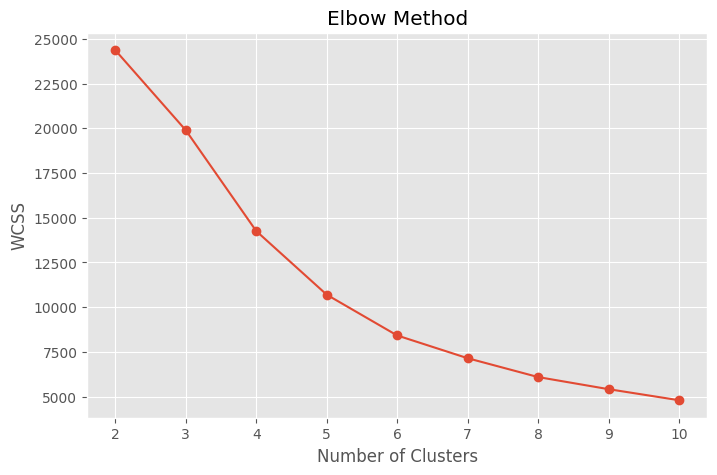

In [10]:
wcss=[]

for k in range(2,11):

    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_df)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o"
)


plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()


In [11]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    scaled_df
)

rfm.head()

,Recency,Frequency,Monetary,Total_Items,Average_Order_Value,CLV,Cluster
Customer ID,,,,,,,
12346.0,326,12,77556.46,34,6463.038333,930677.52,1
12347.0,2,8,4921.53,222,615.191250,39372.24,1
12348.0,75,5,2019.40,51,403.880000,10097.00,1
12349.0,19,4,4428.69,175,1107.172500,17714.76,1
12350.0,310,1,334.40,17,334.400000,334.40,0


In [12]:
score = silhouette_score(
    scaled_df,
    rfm["Cluster"]
)

print("Silhouette Score :",round(score,3))

Silhouette Score : 0.492


In [13]:
rfm["Cluster"].value_counts()

Cluster
1    3799
0    2068
2      10
3       1
Name: count, dtype: int64

In [14]:
cluster_profile = (
    rfm.groupby("Cluster")[features]
       .mean()
       .round(2)
)

cluster_profile

,Recency,Frequency,Monetary,Total_Items,Average_Order_Value,CLV
Cluster,,,,,,
0,455.29,2.14,720.40,40.03,333.08,2995.22
1,63.67,8.00,3534.10,169.02,388.96,93173.96
2,2.60,214.30,229050.83,5452.30,1336.87,44206014.90
3,1.00,2.00,168472.50,3.00,84236.25,336945.00


In [15]:
pca = PCA(n_components=2)

components = pca.fit_transform(
    scaled_df
)

pca_df = pd.DataFrame({

    "PCA1":components[:,0],

    "PCA2":components[:,1],

    "Cluster":rfm["Cluster"]

})

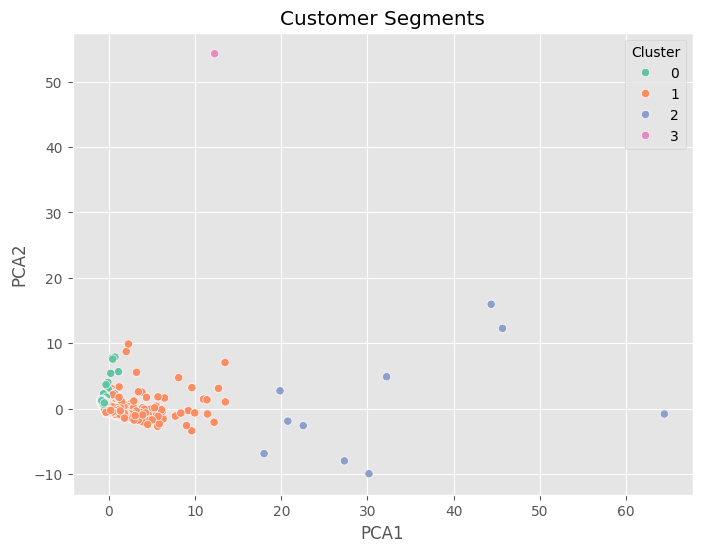

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=pca_df,

    x="PCA1",

    y="PCA2",

    hue="Cluster",

    palette="Set2"

)

plt.title("Customer Segments")

plt.show()

In [17]:
segment_names = {

0:"High Value",

1:"Loyal",

2:"At Risk",

3:"Low Value"

}

rfm["Segment"] = rfm["Cluster"].map(
    segment_names
)

rfm.head()

,Recency,Frequency,Monetary,Total_Items,Average_Order_Value,CLV,Cluster,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,34,6463.038333,930677.52,1,Loyal
12347.0,2,8,4921.53,222,615.191250,39372.24,1,Loyal
12348.0,75,5,2019.40,51,403.880000,10097.00,1,Loyal
12349.0,19,4,4428.69,175,1107.172500,17714.76,1,Loyal
12350.0,310,1,334.40,17,334.400000,334.40,0,High Value


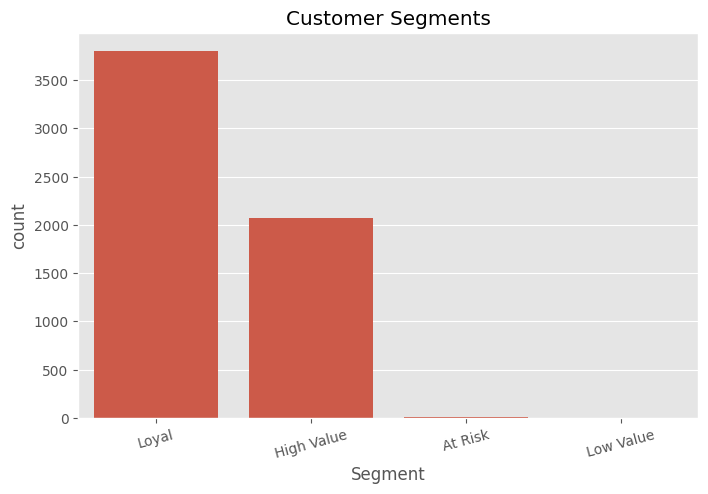

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Segment",
    data=rfm,
    order=rfm["Segment"].value_counts().index
)

plt.title("Customer Segments")

plt.xticks(rotation=15)

plt.show()

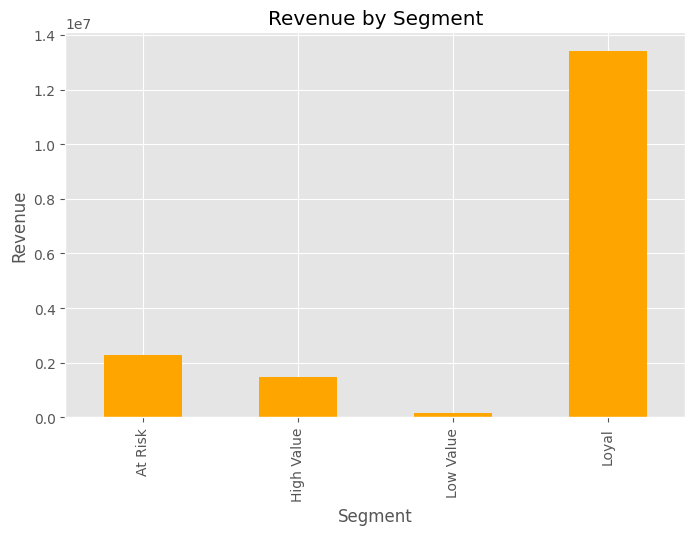

In [19]:
segment_sales = (
    rfm.groupby("Segment")["Monetary"]
       .sum()
)

plt.figure(figsize=(8,5))

segment_sales.plot(
    kind="bar",
    color="orange"
)

plt.ylabel("Revenue")

plt.title("Revenue by Segment")

plt.show()

In [20]:
segment_profile = (
    rfm.groupby("Segment")[
        [
            "Recency",
            "Frequency",
            "Monetary",
            "Average_Order_Value",
            "CLV"
        ]
    ]
    .mean()
)

segment_profile

,Recency,Frequency,Monetary,Average_Order_Value,CLV
Segment,,,,,
At Risk,2.600000,214.300000,229050.827000,1336.865848,4.420601e+07
High Value,455.286267,2.139749,720.400562,333.084236,2.995218e+03
Low Value,1.000000,2.000000,168472.500000,84236.250000,3.369450e+05
Loyal,63.666754,8.001843,3534.097166,388.962852,9.317396e+04


In [21]:
print("="*60)

print("BUSINESS RECOMMENDATIONS")

print("="*60)

print("High Value  -> VIP rewards and exclusive offers.")

print("Loyal -> Membership programs and cross-selling.")

print("At Risk -> Win-back campaigns and personalized discounts.")

print("Low Value -> Promotional offers and product discovery.")

BUSINESS RECOMMENDATIONS
High Value  -> VIP rewards and exclusive offers.
Loyal -> Membership programs and cross-selling.
At Risk -> Win-back campaigns and personalized discounts.
Low Value -> Promotional offers and product discovery.


In [22]:
joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Models Saved Successfully!")

Models Saved Successfully!


In [23]:
rfm.to_csv(
    "customer_segments.csv"
)

rfm.head()

,Recency,Frequency,Monetary,Total_Items,Average_Order_Value,CLV,Cluster,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,34,6463.038333,930677.52,1,Loyal
12347.0,2,8,4921.53,222,615.191250,39372.24,1,Loyal
12348.0,75,5,2019.40,51,403.880000,10097.00,1,Loyal
12349.0,19,4,4428.69,175,1107.172500,17714.76,1,Loyal
12350.0,310,1,334.40,17,334.400000,334.40,0,High Value


In [24]:
print("="*60)

print("SEGMENTATION SUMMARY")

print("="*60)

print("Customers :",len(rfm))

print("Clusters :",rfm["Cluster"].nunique())

print("Silhouette Score :",round(score,3))

print("\nSegment Counts\n")

print(rfm["Segment"].value_counts())

SEGMENTATION SUMMARY
Customers : 5878
Clusters : 4
Silhouette Score : 0.492

Segment Counts

Segment
Loyal         3799
High Value    2068
At Risk         10
Low Value        1
Name: count, dtype: int64
